In [14]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt


In [15]:
import pandas as pd

path = "../app/weekly_sales.csv"

weekly_ml = pd.read_csv(path)

print("Loaded successfully")
print(weekly_ml.shape)

Loaded successfully
(91, 14)


In [16]:
weekly_ml["Date"] = pd.to_datetime(weekly_ml["Date"])

data = weekly_ml.sort_values("Date").reset_index(drop=True)

features = [c for c in data.columns if c not in ["Weekly_Sales", "Date"]]

In [17]:
data = weekly_ml.copy().reset_index(drop=True)

features = [c for c in data.columns if c not in ["Weekly_Sales", "Date"]]

initial_train_size = 80
horizon = 4
step = 4

mape_scores = []
fold_dates = []

In [18]:
# Walk-forward parameters

initial_train_size = 80
horizon = 4
step = 4

mape_scores = []
fold_dates = []
all_preds = []
all_actuals = []

for start in range(initial_train_size, len(data) - horizon + 1, step):

   
    train = data.iloc[:start]
    test  = data.iloc[start:start + horizon]

    xtrain = train[features]
    ytrain = train["Weekly_Sales"]

    xtest  = test[features]
    ytest  = test["Weekly_Sales"]

   
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(xtrain, ytrain)

    preds = model.predict(xtest)


    all_preds.extend(preds)
    all_actuals.extend(ytest.values)

    # MAPE per fold
    mape = mean_absolute_percentage_error(ytest, preds) * 100
    mape_scores.append(mape)

    fold_dates.append(test["Date"].iloc[-1])

In [19]:

results_df = pd.DataFrame({
    "Fold_End_Date": fold_dates,
    "MAPE (%)": mape_scores
})

# overall_mape = mean_absolute_percentage_error(all_actuals, all_preds) * 100
overall_mape = mean_absolute_percentage_error(all_actuals, all_preds) * 100

print("Walk-forward validation completed.")
print(f"Overall MAPE: {overall_mape:.2f}%")
print(results_df)

Walk-forward validation completed.
Overall MAPE: 1.26%
  Fold_End_Date  MAPE (%)
0    2012-09-07  0.960161
1    2012-10-05  1.552859


In [20]:
forecast_df = pd.DataFrame({
    "Date": data["Date"].iloc[initial_train_size:initial_train_size + len(all_preds)],
    "Actual": all_actuals,
    "Predicted": all_preds
})

The model demonstrates high predictive accuracy, with average forecasting error of only 1.26%.

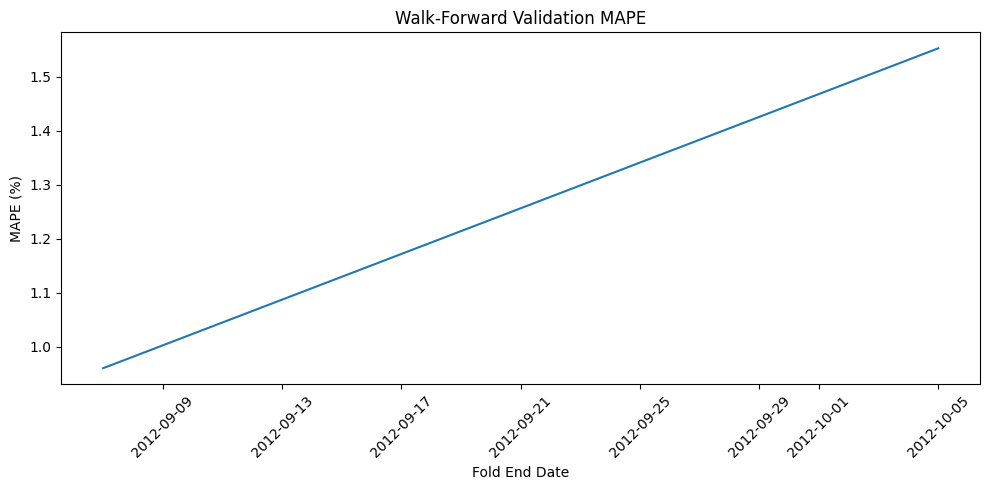

In [21]:
plt.figure(figsize=(10,5))
plt.plot(results_df["Fold_End_Date"], results_df["MAPE (%)"])
plt.title("Walk-Forward Validation MAPE")
plt.xlabel("Fold End Date")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

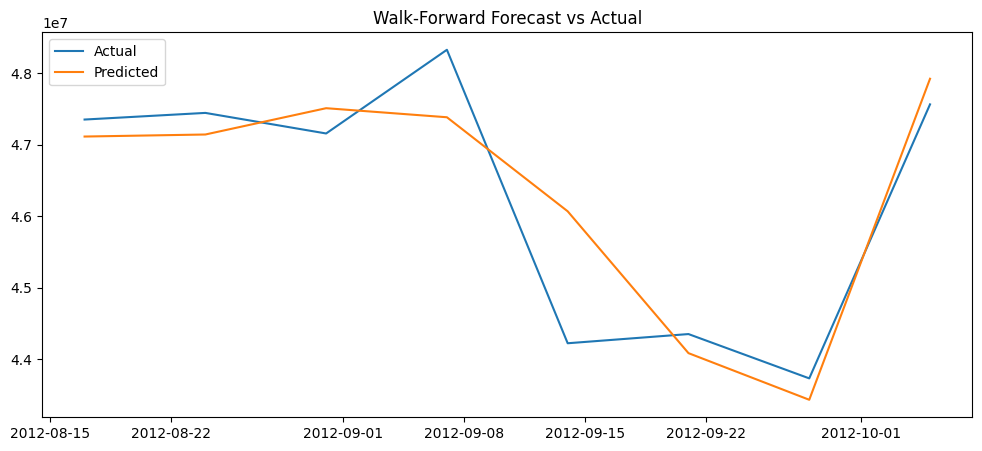

In [22]:
plt.figure(figsize=(12,5))
plt.plot(forecast_df["Date"], forecast_df["Actual"], label="Actual")
plt.plot(forecast_df["Date"], forecast_df["Predicted"], label="Predicted")
plt.legend()
plt.title("Walk-Forward Forecast vs Actual")
plt.show()

In [23]:
forecast_df.to_csv("../outputs/backtest_predictions.csv", index=False)

In [24]:
results_df.to_csv("../outputs/backtest_metrics.csv", index=False)